In [1]:
import pandas as pd

# Leer dataset
df = pd.read_excel('Teleworld.xlsx')

# Muestra del dataset
print("Primeras 5 filas del dataset")
print(df.head())

# Selección de variables numéricas del dataset
variables_numericas = df[['Ingreso', 'Costo', 'margen']]

# Ejecucion de Estadistica Descriptiva
print("Estadistica descriptiva del dataset")

print("\nMedia")
print(variables_numericas.mean().round(2))

print("\nMediana")
print(variables_numericas.median().round(2))

print("\nDesviación estándar")
print(variables_numericas.std().round(2))

print("\nMínimo")
print(variables_numericas.min().round(2))

print("\nMáximo")
print(variables_numericas.max().round(2))



Primeras 5 filas del dataset
   Periodo  Dia EquipoSim     Tipo     Subtipo    Marca        Gama  Ingreso  \
0   202401    1    Equipo  Celular  Smartphone  Samsung  5. Premium  2126.47   
1   202401   20    Equipo  Celular  Smartphone    Apple     4. High  1221.14   
2   202401   14    Equipo  Celular  Smartphone    Apple     4. High  1199.08   
3   202401   27    Equipo  Celular  Smartphone   Xiaomi     4. High  1168.28   
4   202401   12    Equipo  Celular  Smartphone    Apple  5. Premium  4208.57   

     Costo  margen Tipo Venta       CanalVenta   CadenaDealer Departamento  \
0  2015.47   111.0       Reno  TIENDAS PROPIAS  TP MEGA PLAZA         LIMA   
1  1110.14   111.0         VR  GRANDES TIENDAS           SAGA      UCAYALI   
2  1079.08   120.0         VR  GRANDES TIENDAS         TOTTUS   SAN MARTIN   
3   994.28   174.0         VR            ISLAS           ISLA          ICA   
4  4106.57   102.0         VR          Tiendas      LDIAZ4-TE         LIMA   

     Canal         Su

In [2]:
# Proceso ETL
# Cantidad de filas iniciales del dataset
filas_iniciales = df.shape[0]
print(f"Filas iniciales: {filas_iniciales}")

Filas iniciales: 19421


In [3]:
# Verificar cantidad de valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())



Valores nulos por columna:
Periodo            0
Dia                0
EquipoSim          0
Tipo               0
Subtipo            0
Marca              0
Gama               0
Ingreso            0
Costo              0
margen             0
Tipo Venta         0
CanalVenta         1
CadenaDealer    3284
Departamento     147
Canal              0
SubCanal           0
Cluster          147
dtype: int64


In [4]:
# Eliminar filas que contengan valores nulos
df = df.dropna()

In [5]:
# Filas después de eliminar nulos
filas_sin_nulos = df.shape[0]
print(f"\nFilas después de eliminar nulos: {filas_sin_nulos}")


Filas después de eliminar nulos: 16115


In [6]:
# Eliminar filas duplicadas
df = df.drop_duplicates()

In [7]:
# Filas después de eliminar duplicados
filas_sin_duplicados = df.shape[0]
print(f"Filas después de eliminar duplicados: {filas_sin_duplicados}")

Filas después de eliminar duplicados: 15267


In [8]:
# Convertir Periodo a string antes de asignar el nuevo formato
df.loc[:, 'Periodo'] = df['Periodo'].astype(str)

# Aplicar formato YYYY/MM
df.loc[:, 'Periodo'] = df['Periodo'].str[:4] + '/' + df['Periodo'].str[4:]


/tmp/ipython-input-1761529478.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['202401' '202401' '202401' ... '202405' '202405' '202405']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'Periodo'] = df['Periodo'].astype(str)


In [9]:
# Limpiar columna Gama
# Quitar numeración: "1.Low" -> "Low"
df.loc[:, 'Gama'] = df['Gama'].str.replace(r'^\d+\.', '', regex=True)

In [10]:
# Redondear columnas numéricas a 2 decimales
columnas_numericas = ['Ingreso', 'Costo', 'margen']
df.loc[:, columnas_numericas] = df[columnas_numericas].round(2)

In [11]:
# Eliminar columna Subcanal - (misma información que CanalVenta)
df = df.drop(columns=['SubCanal'])


In [12]:
# Reemplazar "_" por espacio en CadenaDealer
df.loc[:, 'CadenaDealer'] = df['CadenaDealer'].str.replace('_', ' ', regex=False)

In [13]:
# Normalizar columna Cluster - "Cluster A" -> "A"
df.loc[:, 'Cluster'] = df['Cluster'].str.replace('Cluster ', '', regex=False)

In [14]:
filas_finales = df.shape[0]
print(f"Filas finales: {filas_finales}")
print(f"Filas eliminadas: {filas_iniciales - filas_finales}")

Filas finales: 15267
Filas eliminadas: 4154


In [15]:
# Normalizar formato de texto

columnas_texto = ['CanalVenta', 'CadenaDealer', 'Canal', 'Departamento']

for col in columnas_texto:
    df.loc[:, col] = df[col].str.lower().str.title()


In [16]:
# Revisar las primeras filas después del ETL
print("\nDataset después del proceso ETL:")
print(df.head())



Dataset después del proceso ETL:
   Periodo  Dia EquipoSim     Tipo     Subtipo    Marca      Gama  Ingreso  \
0  2024/01    1    Equipo  Celular  Smartphone  Samsung   Premium  2126.47   
1  2024/01   20    Equipo  Celular  Smartphone    Apple      High  1221.14   
2  2024/01   14    Equipo  Celular  Smartphone    Apple      High  1199.08   
3  2024/01   27    Equipo  Celular  Smartphone   Xiaomi      High  1168.28   
4  2024/01   12    Equipo  Celular  Smartphone    Apple   Premium  4208.57   

     Costo  margen Tipo Venta       CanalVenta   CadenaDealer Departamento  \
0  2015.47   111.0       Reno  Tiendas Propias  Tp Mega Plaza         Lima   
1  1110.14   111.0         VR  Grandes Tiendas           Saga      Ucayali   
2  1079.08   120.0         VR  Grandes Tiendas         Tottus   San Martin   
3   994.28   174.0         VR            Islas           Isla          Ica   
4  4106.57   102.0         VR          Tiendas      Ldiaz4-Te         Lima   

     Canal Cluster  
0  Tien

In [17]:
# Guardar dataset limpio en un nuevo archivo Excel
df.to_excel('Teleworld_ETL.xlsx', index=False)

print("Archivo 'Teleworld_ETL.xlsx' generado correctamente")


Archivo 'Teleworld_ETL.xlsx' generado correctamente


In [18]:
import matplotlib.pyplot as plt

In [19]:
# Contar cantidad de equipos vendidos por marca
ventas_por_marca = df['Marca'].value_counts()
print(ventas_por_marca)

Marca
Motorola    3438
Bmobile     3220
Samsung     2906
Xiaomi      2784
ZTE         2320
POCO         198
Alcatel      133
Vivo         103
Nokia         45
Realme        43
Azumi         42
Apple         26
LG             7
Huawei         2
Name: count, dtype: int64


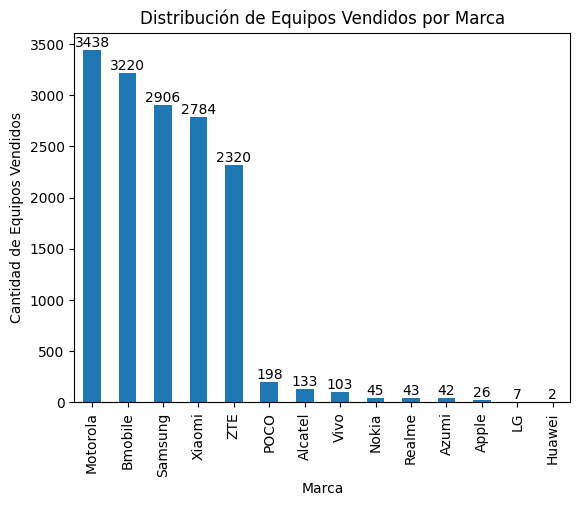

In [20]:
# Crear figura
plt.figure()

# Crear gráfico de barras
ax = ventas_por_marca.plot(kind='bar')

# Títulos y etiquetas
plt.title('Distribución de Equipos Vendidos por Marca')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Equipos Vendidos')

# Agregar valores encima de cada barra
for i, valor in enumerate(ventas_por_marca):
    ax.text(i, valor, str(valor), ha='center', va='bottom')

# Mostrar gráfico
plt.show()

In [21]:
# Equipos vendidos por cada canal de venta
ventas_por_marca = df['CanalVenta'].value_counts()
print(ventas_por_marca)

CanalVenta
Grandes Tiendas                  10876
Islas                             1878
Tiendas Propias Franquiciadas     1750
Grandes Tiendas Especialistas      255
Tiendas Propias                    254
Mayoristas                         131
Otros                               75
Tiendas                             44
Conecta Plus                         3
S2S                                  1
Name: count, dtype: int64


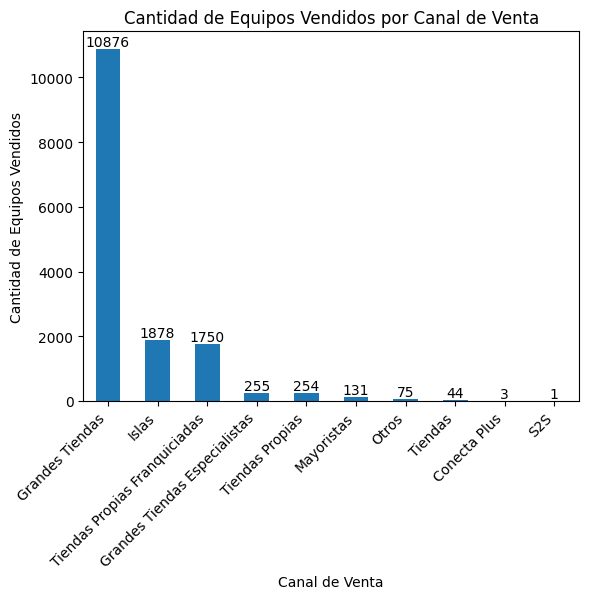

In [22]:
# Contar cantidad de equipos vendidos por canal de venta
ventas_por_canal = df['CanalVenta'].value_counts()

# Crear figura
plt.figure()

# Crear gráfico de barras
ax = ventas_por_canal.plot(kind='bar')

# Títulos y etiquetas
plt.title('Cantidad de Equipos Vendidos por Canal de Venta')
plt.xlabel('Canal de Venta')
plt.ylabel('Cantidad de Equipos Vendidos')

# Valores para cada barra
for i, valor in enumerate(ventas_por_canal):
    ax.text(i, valor, str(valor), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')

# Mostrar gráfico
plt.show()

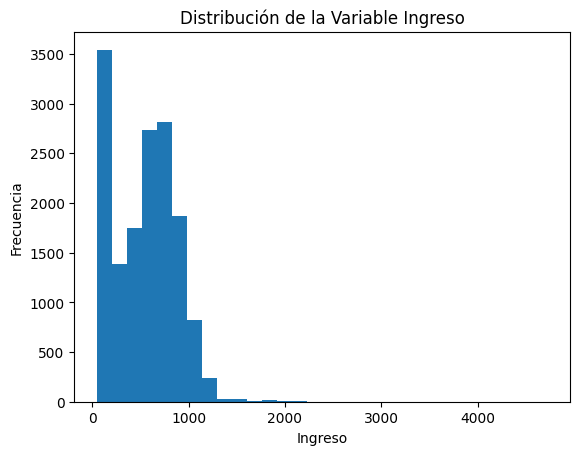

In [23]:
# Crear histograma de ingresos
plt.figure()
plt.hist(df['Ingreso'], bins=30)

# Títulos y etiquetas
plt.title('Distribución de la Variable Ingreso')
plt.xlabel('Ingreso')
plt.ylabel('Frecuencia')

# Mostrar gráfico
plt.show()

In [24]:
import numpy as np

frecuencias, rangos = np.histogram(df['Ingreso'], bins=30)

print("Frecuencias por rango:")
print(frecuencias)

print("\nRangos:")
print(rangos)


Frecuencias por rango:
[3541 1383 1747 2737 2817 1868  827  234   31   29   11   17   12    4
    2    0    0    1    1    0    1    0    1    0    1    0    1    0
    0    1]

Rangos:
[  47.66   203.724  359.788  515.852  671.916  827.98   984.044 1140.108
 1296.172 1452.236 1608.3   1764.364 1920.428 2076.492 2232.556 2388.62
 2544.684 2700.748 2856.812 3012.876 3168.94  3325.004 3481.068 3637.132
 3793.196 3949.26  4105.324 4261.388 4417.452 4573.516 4729.58 ]


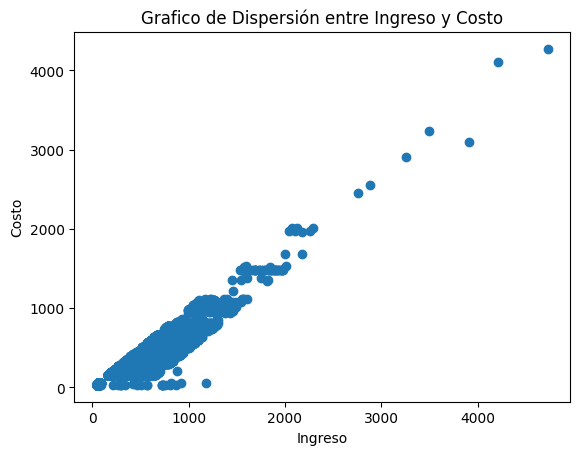

In [38]:
# Crear gráfico de dispersión Ingreso vs Costo
plt.figure()
plt.scatter(df['Ingreso'], df['Costo'])

# Títulos y etiquetas
plt.title('Grafico de Dispersión entre Ingreso y Costo')
plt.xlabel('Ingreso')
plt.ylabel('Costo')

# Mostrar gráfico
plt.show()

Marca       Alcatel  Apple  Azumi  Bmobile  Huawei  LG  Motorola  Nokia  POCO  \
Tipo Venta                                                                      
Porta            56      9     18      960       0   2      1737     17   100   
Reno             49      9     14     1400       2   5      1445     19    82   
VR               28      8     10      860       0   0       256      9    16   

Marca       Realme  Samsung  Vivo  Xiaomi   ZTE  
Tipo Venta                                       
Porta           24     1260    36    1254   913  
Reno            13     1356    48    1206  1062  
VR               6      290    19     324   345  


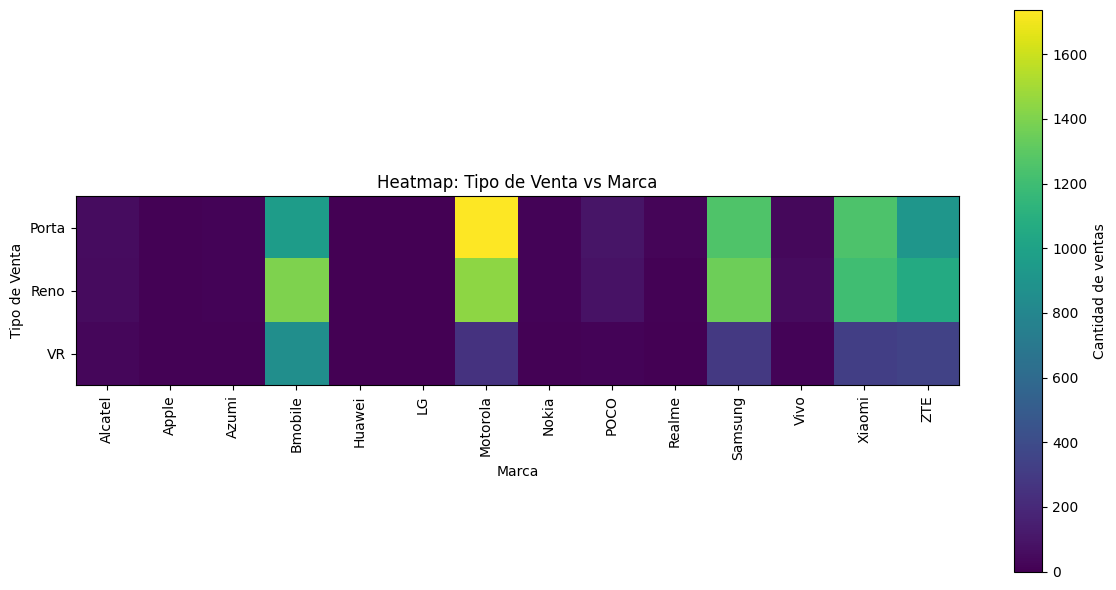

In [26]:
# Crear tabla cruzada
tabla = pd.crosstab(df['Tipo Venta'], df['Marca'])
print(tabla)

# Crear figura
plt.figure(figsize=(12, 6))

# Crear heatmap
plt.imshow(tabla.values)

# Títulos y etiquetas
plt.title('Heatmap: Tipo de Venta vs Marca')
plt.xlabel('Marca')
plt.ylabel('Tipo de Venta')

# Configurar ejes
plt.xticks(range(len(tabla.columns)), tabla.columns, rotation=90)
plt.yticks(range(len(tabla.index)), tabla.index)

plt.colorbar(label='Cantidad de ventas')

plt.tight_layout()

# 8. Mostrar gráfico
plt.show()


In [27]:
# Tipo Venta trae más ingresos, Porta o VR
venta_ingresos = df.groupby('Tipo Venta')['Ingreso'].sum()
print(venta_ingresos)

Tipo Venta
Porta    3774503.99
Reno     3665237.92
VR        771825.68
Name: Ingreso, dtype: float64


In [28]:
# Marca con mejor margen en Cluster B
# Filtrado de registros del Clúster B
df_cluster_b = df[df['Cluster'] == 'B']

# Agrupacion por Marca y suma del margen
margen_por_marca = df_cluster_b.groupby('Marca')['margen'].sum()

print(margen_por_marca)

# Ordenar de mayor a menor para ver la mejor marca
margen_por_marca_ordenado = margen_por_marca.sort_values(ascending=False)

print(margen_por_marca_ordenado)


Marca
Alcatel      12206.24
Apple         1118.83
Azumi          388.04
Bmobile      15665.17
Huawei         123.00
LG             911.00
Motorola    301133.04
Nokia          336.48
POCO         11824.03
Realme        3032.23
Samsung     215127.86
Vivo          6771.47
Xiaomi      135758.82
ZTE         112638.09
Name: margen, dtype: float64
Marca
Motorola    301133.04
Samsung     215127.86
Xiaomi      135758.82
ZTE         112638.09
Bmobile      15665.17
Alcatel      12206.24
POCO         11824.03
Vivo          6771.47
Realme        3032.23
Apple         1118.83
LG             911.00
Azumi          388.04
Nokia          336.48
Huawei         123.00
Name: margen, dtype: float64


In [29]:
# Canal con mayores costos
canal_mayor_costo = df.groupby('Canal')['Costo'].sum()
print(canal_mayor_costo)

canal_mayor_costo_ord = canal_mayor_costo.sort_values(ascending=False)
print(canal_mayor_costo_ord)


Canal
Islas       720891.56
Otros        66671.76
Retail     4145753.22
Tiendas     605627.93
Name: Costo, dtype: float64
Canal
Retail     4145753.22
Islas       720891.56
Tiendas     605627.93
Otros        66671.76
Name: Costo, dtype: float64


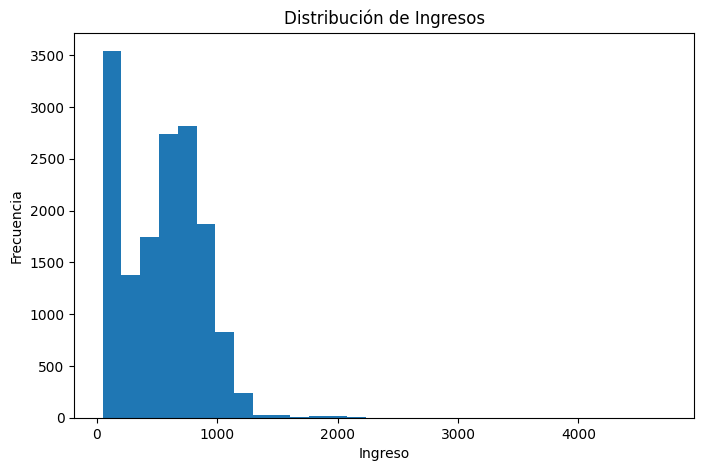

In [30]:
# Histograma de ingresos
plt.figure(figsize=(8,5))
plt.hist(df['Ingreso'], bins=30)
plt.title('Distribución de Ingresos')
plt.xlabel('Ingreso')
plt.ylabel('Frecuencia')
plt.show()


Bigote inferior: 47.66
Q1 (25%): 227.97
Mediana (50%): 580.46
Q3 (75%): 782.34
Bigote Superior: 1613.89


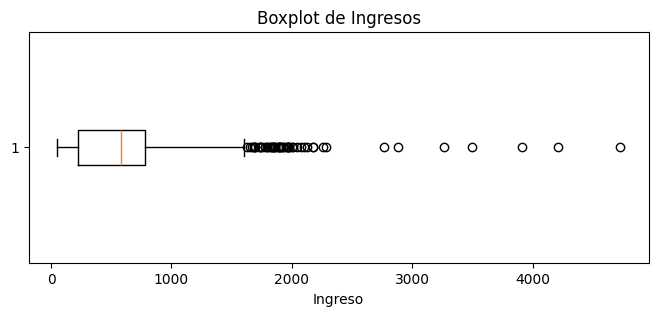

In [37]:
# Boxplot de ingresos
# Estadisticas del boxplot
bigote_inferior = df['Ingreso'].min()
q1 = df['Ingreso'].quantile(0.25)
mediana = df['Ingreso'].median()
q3 = df['Ingreso'].quantile(0.75)
rango_intercuartil = q3 - q1
bigote_superior = q3 + 1.5 * rango_intercuartil

print(f"Bigote inferior: {bigote_inferior:.2f}")
print(f"Q1 (25%): {q1:.2f}")
print(f"Mediana (50%): {mediana:.2f}")
print(f"Q3 (75%): {q3:.2f}")
print(f"Bigote Superior: {bigote_superior:.2f}")

plt.figure(figsize=(8,3))
plt.boxplot(df['Ingreso'], vert=False)
plt.title('Boxplot de Ingresos')
plt.xlabel('Ingreso')
plt.show()
